In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
                             precision_recall_curve, roc_curve, auc)

import joblib

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
import matplotlib
import sklearn
import xgboost
import lightgbm
import catboost

print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(sns.__version__)

print(sklearn.__version__)
print(xgboost.__version__)
print(lightgbm.__version__)
print(catboost.__version__)

2.2.6
2.3.3
3.10.8
0.13.2
1.7.2
3.1.3
4.6.0
1.2.8


In [ ]:
SEED = 42

np.random.seed(SEED)

# data import

In [ ]:
path = '/home/leewen/code/physionet'

In [ ]:
X_train_linear = pd.read_csv(path + '/X_train_linear.csv')
X_test_linear = pd.read_csv(path + '/X_test_linear.csv')
X_train_smote = pd.read_csv(path + '/X_train_smote.csv')
X_test_smote = pd.read_csv(path + '/X_test_smote.csv')
X_train_tree = pd.read_csv(path + '/X_train_tree.csv')
X_test_tree = pd.read_csv(path + '/X_test_tree.csv')
y_train = pd.read_csv(path + '/y_train.csv')
y_test = pd.read_csv(path + '/y_test.csv')

In [ ]:
X_train_linear.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Anion_Gap,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,0.043806,0.019069,0.005296,-0.037088,-0.175259,-0.207376,0.617544,0.388429,0.608342,0.339159,-0.208014,-0.241122,0.011620,-0.095195,0.043514,-0.458196,-0.019451,-0.017062,0.034924,0.041906,0.110260,-1.525112,-1.866613,-1.200147,-0.005787,-0.394672,0.369010,-0.976697,-0.382628,1.585857,0.566954,1.057045,1.123359,-0.693337,-1.483015,-0.860751,-0.837875,0.889310,1.097191,0.876515,1.027405,-2.150841,-0.865905,-1.976843,-1.327389,-2.047022,-0.194677,0.459301,0.638111,-0.496313,-0.065618,0.007035,0.476987,0.162761,0.304278,1.262430,0.0,-0.512210,-0.247878,-0.374130,0.259736,0.257381,0.242835,-0.165738,0.111927,-1.493286,-1.094913,-0.520759,0.286135,-0.687199,0.041722,1.192960,-0.005638,0.542476,-0.138047,-1.314606,-1.17

In [ ]:
X_test_linear.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Anion_Gap,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,-0.430781,-0.216540,-0.482986,-0.281166,-0.291522,-0.294959,-0.077404,-0.103939,-0.094208,-0.113626,1.452775,1.285497,-0.268303,-0.270024,-0.241623,0.691479,-0.019451,-0.017062,-0.448363,-0.459321,-0.454460,0.636300,0.55289,-0.152063,1.017896,0.711876,1.411458,0.555026,1.036857,-1.065412,-1.432801,0.043769,-1.028674,0.384648,-0.305524,0.242322,0.134327,-0.603095,-0.274274,-0.326557,-0.369233,-0.538503,0.067993,0.320756,-1.100921,-0.486345,-1.357204,-0.240267,-0.926548,-0.299186,-0.774756,-0.694056,-0.251297,-0.230230,-0.003023,0.025472,0.0,0.154566,-0.537819,-0.628520,-1.244617,-1.798710,-1.354391,-1.291316,-1.373396,-0.117568,-0.072738,-0.115809,-0.233979,-0.222758,-0.164222,0.090292,0.120361,-0.013630,0.059118,-

In [ ]:
X_train_smote.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Anion_Gap,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,3.0,2.9,3.0,2.9,76.0,76.0,339.0,339.0,500.0,500.0,0.6,0.6,26.0,27.0,26.333333,18.571429,153.0,153.0,1.4,1.6,1.500000,0.50,0.5,0.411765,10.0,11.0,10.0,11.0,10.413793,260.0,125.0,260.0,180.666667,20.0,18.0,18.0,22.0,37.1,34.2,38.2,35.880000,47.0,71.0,41.0,83.0,57.071429,9.222220,4.5,4.4,3.5,4.5,4.133333,3.1,3.1,12.903226,54.838710,1.0,1.7,1.7,2.1,140.0,140.0,138.0,140.0,139.333333,27.0,27.0,42.0,227.0,65.0,162.500000,7.47,7.32,7.47,7.377692,68.0,62.0,19.0,28.0,19.071762,98.0,96.0,36.2,36.2,37.6,37.016071,0.357149,2185.0,0.223430,1.787443,0.496472,10.3,10.3,12.2,56.8,67.4,66.0,51.0,73.0,61.035088,82.0,91.00,68.00,96.0,79.892857,6.317878,114.0,123.0,100.0,134.0,113.561404,7.618159,0.28,0.000000,0.693147,0.693147,0.693

In [ ]:
X_test_smote.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Anion_Gap,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,2.8,2.8,2.8,2.80,66.0,68.0,49.0,50.0,65.0,70.0,5.6,5.6,20.0,23.0,20.500000,33.333333,153.0,153.0,0.7,0.8,0.725000,1.0,1.0,0.526120,15.0,15.0,15.0,15.0,15.000000,73.0,67.0,176.0,96.750000,25.0,23.0,23.0,26.0,28.3,27.1,32.5,29.680000,79.0,87.0,73.0,88.0,79.910714,3.824689,4.0,3.6,3.6,4.0,3.800000,1.9,2.3,0.000000,10.000000,1.0,2.0,1.6,2.0,133.0,131.0,131.0,135.0,133.250000,40.0,34.0,46.0,171.0,82.0,146.0,7.38,7.33,7.44,7.387500,61.0,61.0,19.0,28.0,19.071762,98.0,96.0,36.3,35.9,37.3,36.677778,0.450071,1788.0,0.106045,0.848356,0.353371,4.9,4.2,4.9,94.3,94.3,57.0,41.0,66.0,57.581818,79.67,80.67,66.00,87.67,77.951455,4.670848,125.0,120.0,106.0,137.0,118.690909,6.268300,0.28,1.098612,1.098612,1.098612,1.098612,1.609438,0

In [ ]:
X_train_tree.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Anion_Gap,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,NaN,NaN,NaN,NaN,76.0,76.0,339.0,339.0,500.0,500.0,0.6,0.6,26.0,27.0,26.333333,18.571429,NaN,NaN,1.4,1.6,1.500000,0.50,0.5,0.411765,10.0,11.0,10.0,11.0,10.413793,260.0,125.0,260.0,180.666667,20.0,18.0,18.0,22.0,37.1,34.2,38.2,35.880000,47.0,71.0,41.0,83.0,57.071429,9.222220,4.5,4.4,3.5,4.5,4.133333,3.1,3.1,12.903226,54.838710,1.0,1.7,1.7,2.1,140.0,140.0,138.0,140.0,139.333333,27.0,27.0,42.0,227.0,65.0,162.500000,7.47,7.32,7.47,7.377692,68.0,62.0,NaN,NaN,NaN,98.0,96.0,36.2,36.2,37.6,37.016071,0.357149,2185.0,0.223430,1.787443,0.496472,10.3,10.3,12.2,56.8,67.4,66.0,51.0,73.0,61.035088,82.0,91.00,68.00,96.0,79.892857,6.317878,114.0,123.0,100.0,134.0,113.561404,7.618159,NaN,0.000000,0.693147,0.693147,0.693147,1.386294,

In [ ]:
X_test_tree.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Anion_Gap,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,2.8,2.8,2.8,2.80,66.0,68.0,49.0,50.0,65.0,70.0,5.6,5.6,20.0,23.0,20.500000,33.333333,NaN,NaN,0.7,0.8,0.725000,NaN,NaN,NaN,15.0,15.0,15.0,15.0,15.000000,73.0,67.0,176.0,96.750000,25.0,23.0,23.0,26.0,28.3,27.1,32.5,29.680000,79.0,87.0,73.0,88.0,79.910714,3.824689,4.0,3.6,3.6,4.0,3.800000,NaN,NaN,NaN,NaN,NaN,2.0,1.6,2.0,133.0,131.0,131.0,135.0,133.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,61.0,NaN,NaN,NaN,NaN,NaN,36.3,35.9,37.3,36.677778,0.450071,1788.0,0.106045,0.848356,0.353371,4.9,4.2,4.9,94.3,94.3,57.0,41.0,66.0,57.581818,79.67,80.67,66.00,87.67,77.951455,4.670848,125.0,120.0,106.0,137.0,118.690909,6.268300,NaN,1.098612,1.098612,1.098612,1.098612,1.609438,0.693147,0.000000,1.609438,0.000000,2.564949,1.6

In [ ]:
y_train.head(10)

,In-hospital_death
0,0
1,0
2,0
3,0
4,1
5,0
6,0
7,0
8,0
9,1


In [ ]:
y_test.head (10)

,In-hospital_death
0,0
1,0
2,0
3,0
4,1
5,0
6,0
7,0
8,0
9,1


In [ ]:
X_train_linear.shape, X_test_linear.shape, X_train_smote.shape, X_test_smote.shape, X_train_tree.shape, X_test_tree.shape, y_train.shape, y_test.shape

((9588, 255),
 (2398, 255),
 (9588, 255),
 (2398, 255),
 (9588, 255),
 (2398, 255),
 (9588, 1),
 (2398, 1))

# upsampling

In [ ]:
sm = SMOTE(sampling_strategy='auto', random_state=SEED)

In [ ]:
X_linear_sm, y_linear_sm = sm.fit_resample(X_train_linear, y_train)
X_tree_sm, y_tree_sm = sm.fit_resample(X_train_smote, y_train)

In [ ]:
y_linear_sm = y_linear_sm.values.ravel()
y_tree_sm = y_tree_sm.values.ravel()

In [ ]:
X_linear_sm.shape, y_linear_sm.shape, X_tree_sm.shape, y_tree_sm.shape

((16446, 255), (16446,), (16446, 255), (16446,))

In [ ]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# helper function

In [ ]:
def extract_importance(name, strategy, model, feature_names):

    df_imp = pd.DataFrame()

    if hasattr(model, 'feature_importances_'):
        imps = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imps = np.abs(model.coef_[0])
    else:
        return None

    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': imps, 'Model': name, 'Strategy': strategy})
    return df_imp.sort_values(by='Importance', ascending=False)


In [ ]:
results = []
predictions = {}
dfs_importance = []
best_models_smote = {}
best_models_weight = {}

In [ ]:
def evaluate_model(name, strategy, model, X_train, X_test, y_train, y_test, is_tuned=False):

    if not is_tuned:
        print(f'Fitting {name}...')
        model.fit(X_train, y_train)
    else:
        print(f'Using pre-fitted tuned model for {name}...')

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    prc = average_precision_score(y_test, y_prob)

    print(f'Output metrics for {name}...')
    results.append(
       {'Model': name, 'Strategy': strategy,
        'ROC_AUC': roc, 'PR_AUC': prc, 'F1': f1, 'Recall': rec,
        'Precision': prec, 'Specificity': spec, 'Accuracy': acc,
        'TP': tp, 'TN':tn, 'FP': fp, 'FN': fn}
    )

    keys = f'{name}_{strategy}'
    predictions[keys] = (y_test, y_pred, y_prob)

    print(f'Output feature importance for {name}...')
    df_imp = extract_importance(name, strategy, model, X_train.columns)

    if df_imp is not None:
        dfs_importance.append(df_imp)

In [ ]:
def tune_model(name, model, param_grids, X_train, y_train, search_type='random', cv=5, n_iter=10, scoring='recall'):

    if search_type == 'grid':
        search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=cv, scoring=scoring, n_jobs=-1, verbose=1)
    else:
        search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=n_iter, cv=cv, scoring=scoring, n_jobs=-1, verbose=1, random_state=SEED)

    search.fit(X_train, y_train)

    print(f'\n{name} tuned. Best Parameters: {search.best_params_}\n')

    return search.best_estimator_

In [ ]:
def plot_model_comparison(predictions, strategy):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    print(f'\n--- Plotting Curves for Strategy: {strategy} ---\n')

    styles = {'alpha': 0.8}

    for key, (y_test, y_pred, y_prob) in predictions.items():
        if strategy in key:
            model_label = key.replace(f'_{strategy}', '')
            RocCurveDisplay.from_predictions(y_test, y_prob, name=model_label, ax=ax1, curve_kwargs={'alpha': 0.8})
            PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=model_label, ax=ax2, **styles)

    ax1.plot([0, 1], [0, 1], 'k--', label='Random Change')
    ax1.set_title(f'ROC Curves - {strategy}')
    ax1.legend(loc='lower right', fontsize=8)

    baseline_pr = float(y_test.mean())
    ax2.axhline(baseline_pr, color='black', linestyle='-', label=f'Baseline {baseline_pr:.2f}')
    ax2.set_title(f'Precision-Recall Curve - {strategy}', fontsize=8)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_feature_comparison(df_all_importance, strategy, top_n=15):

  top_feature_union = df_all_importance[df_all_importance['Strategy'] == strategy].nlargest(top_n, 'Importance')['Feature'].unique()
  comparison_data = df_all_importance[(df_all_importance['Strategy'] == strategy) & (df_all_importance['Feature'].isin(top_feature_union))]

  g = sns.catplot(data=comparison_data, y='Feature', x='Importance', hue='Model', kind='bar', palette='coolwarm', col='Model', col_wrap=3, sharex=False, height=5, aspect=1.8)
  g.fig.suptitle(f'Top {top_n} Features Driving Mortality Prediction (Strategy: {strategy})', y=1.02, fontsize=12)

  for ax in g.axes.flat:
    ax.set_ylabel('')
    for p in ax.patches:
      width = p.get_width()
      if abs(width) < 1e-4:
            continue
      ax.annotate(f'{width:.2f}', (width, p.get_y() + p.get_height() / 2), ha='left', va='center', fontsize=10)

  plt.tight_layout()
  plt.show()

# models





### samples

In [ ]:
#X_linear_sm, y_linear_sm, X_test_linear, y_test - SMOTE Linear Model
#X_tree_sm, y_tree_sm, X_test_smote, y_test - SMOTE Tree Model
#X_train_linear, y_train, X_test_linear, y_test - Linear Model
#X_train_tree, y_train, X_test_tree, y_test - Tree Model

print(X_linear_sm.shape, y_linear_sm.shape, X_test_linear.shape, y_test.shape)
print(X_tree_sm.shape, y_tree_sm.shape, X_test_smote.shape, y_test.shape)
print(X_train_linear.shape, y_train.shape, X_test_linear.shape, y_test.shape)
print(X_train_tree.shape, y_train.shape, X_test_tree.shape, y_test.shape)

(16446, 255) (16446,) (2398, 255) (2398,)
(16446, 255) (16446,) (2398, 255) (2398,)
(9588, 255) (9588,) (2398, 255) (2398,)
(9588, 255) (9588,) (2398, 255) (2398,)


### models with SMOTE sample

In [ ]:
models_smote = {
    'Logistic': LogisticRegression(C=0.1, max_iter=1000, random_state=SEED),
    'SVC': SVC(C=0.1, probability=True, kernel='rbf', random_state=SEED, cache_size=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='aucpr', scale_pos_weight=1, random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(objective='binary', is_unbalance=False, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1),
    'CatBoost': CatBoostClassifier(loss_function='Logloss', eval_metric='Recall', auto_class_weights=None, random_state=SEED, verbose=0)}

In [ ]:
for name, model in models_smote.items():
  if name in ['Logistic', 'SVC']:
    evaluate_model(name, 'SMOTE', model, X_linear_sm, X_test_linear, y_linear_sm, y_test)
  else:
    evaluate_model(name, 'SMOTE', model, X_tree_sm, X_test_smote, y_tree_sm, y_test)


Fitting Logistic...
Output metrics for Logistic...
Output feature importance for Logistic...
Fitting SVC...
Output metrics for SVC...
Output feature importance for SVC...
Fitting RandomForest...
Output metrics for RandomForest...
Output feature importance for RandomForest...
Fitting XGBoost...
Output metrics for XGBoost...
Output feature importance for XGBoost...
Fitting LightGBM...
Output metrics for LightGBM...
Output feature importance for LightGBM...
Fitting CatBoost...
Output metrics for CatBoost...
Output feature importance for CatBoost...


In [ ]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863310,0.513641,0.514620,0.771930,0.385965,0.795720,0.792327,264,1636,420,78
1,SVC,SMOTE,0.832394,0.416772,0.480749,0.675439,0.373183,0.811284,0.791910,231,1668,388,111
2,RandomForest,SMOTE,0.842863,0.468563,0.477124,0.426901,0.540741,0.939689,0.866555,146,1932,124,196
3,XGBoost,SMOTE,0.852555,0.517836,0.447552,0.374269,0.556522,0.950389,0.868224,128,1954,102,214
4,LightGBM,SMOTE,0.857578,0.505905,0.458844,0.383041,0.572052,0.952335,0.871143,131,1958,98,211
5,CatBoost,SMOTE,0.868124,0.549402,0.454383,0.371345,0.585253,0.956226,0.872811,127,1966,90,215



--- Plotting Curves for Strategy: SMOTE ---



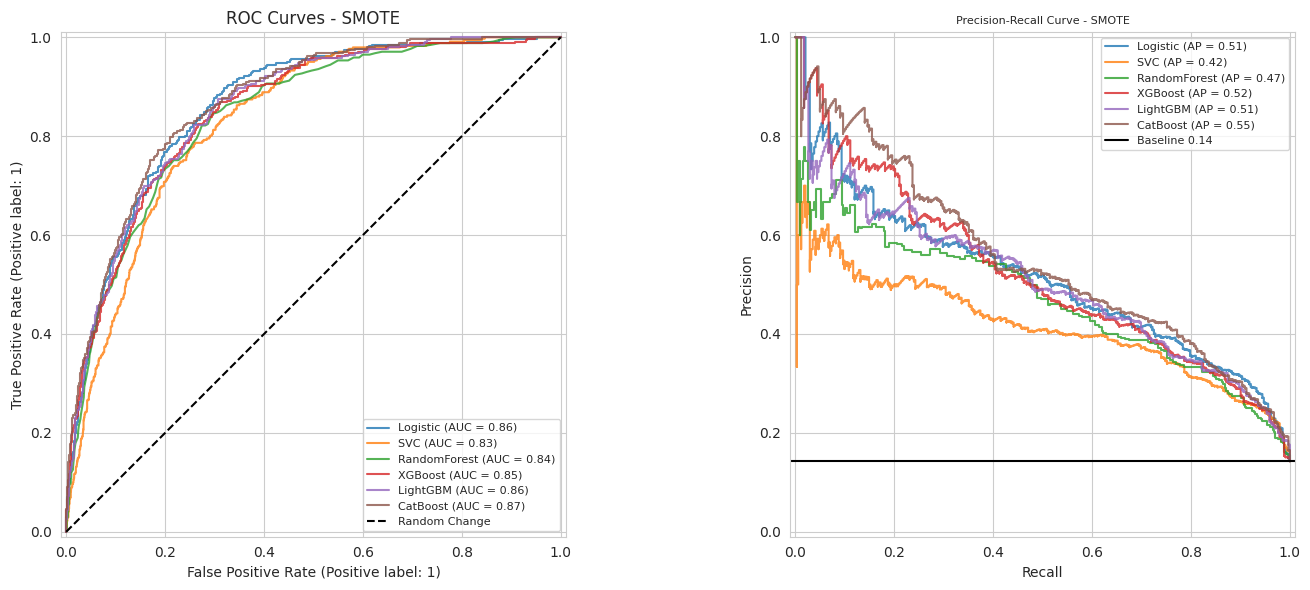

In [ ]:
plot_model_comparison(predictions, 'SMOTE')

### models with SMOTE sample after hyperparameter tuning

In [ ]:
param_grids = {
    'Logistic': {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    'SVC': {'C': [0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto', 0.001, 0.01], 'kernel': ['rbf', 'sigmoid']},
    'RandomForest': {'n_estimators': [100, 200, 300, 500], 'max_depth': [8, 12, 16, 20, None], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']},
    'XGBoost': {'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7, 9], 'min_child_weight': [1, 3, 5], 'n_estimators': [100, 200, 500]},
    'LightGBM': {'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [31, 63, 127], 'n_estimators': [100, 200, 500], 'feature_fraction': [0.7, 0.8, 0.9]},
    'CatBoost': {'depth': [4, 6, 8, 10], 'learning_rate': [0.01, 0.05, 0.1], 'iterations': [100, 200, 500], 'l2_leaf_reg': [1, 3, 5, 9]}}

In [ ]:
for name, model in models_smote.items():
  if name in ['Logistic', 'SVC']:
    best_model = tune_model(name, model, param_grids, X_linear_sm, y_linear_sm, search_type='random', cv=5, n_iter=10, scoring='recall')
    best_models_smote[name] = best_model
    evaluate_model(name, 'Tuned-SMOTE', best_model, X_linear_sm, X_test_linear, y_linear_sm, y_test, is_tuned=True)
  else:
    best_model = tune_model(name, model, param_grids, X_tree_sm, y_tree_sm, search_type='random', cv=5, n_iter=10, scoring='recall')
    best_models_smote[name] = best_model
    evaluate_model(name, 'Tuned-SMOTE', best_model, X_tree_sm, X_test_smote, y_tree_sm, y_test, is_tuned=True)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Logistic tuned. Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.001}

Using pre-fitted tuned model for Logistic...
Output metrics for Logistic...
Output feature importance for Logistic...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



SVC tuned. Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}

Using pre-fitted tuned model for SVC...
Output metrics for SVC...
Output feature importance for SVC...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

RandomForest tuned. Best Parameters: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 12}

Using pre-fitted tuned model for RandomForest...
Output metrics for RandomForest...
Output feature importance for RandomForest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

XGBoost tuned. Best Parameters: {'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01}

Using pre-fitted tuned model for XGBoost...
Output metrics for XGBoost...
Output feature importance for XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

LightGBM tuned. Best Parameters: {'num_leaves': 63, 'n_estimators': 100, 'learning_rate': 0.01, 'feature_fraction': 0.8}

Using pre-fitted tuned model

/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



CatBoost tuned. Best Parameters: {'learning_rate': 0.01, 'l2_leaf_reg': 9, 'iterations': 100, 'depth': 10}

Using pre-fitted tuned model for CatBoost...
Output metrics for CatBoost...
Output feature importance for CatBoost...


In [ ]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863310,0.513641,0.514620,0.771930,0.385965,0.795720,0.792327,264,1636,420,78
1,SVC,SMOTE,0.832394,0.416772,0.480749,0.675439,0.373183,0.811284,0.791910,231,1668,388,111
2,RandomForest,SMOTE,0.842863,0.468563,0.477124,0.426901,0.540741,0.939689,0.866555,146,1932,124,196
3,XGBoost,SMOTE,0.852555,0.517836,0.447552,0.374269,0.556522,0.950389,0.868224,128,1954,102,214
4,LightGBM,SMOTE,0.857578,0.505905,0.458844,0.383041,0.572052,0.952335,0.871143,131,1958,98,211
5,CatBoost,SMOTE,0.868124,0.549402,0.454383,0.371345,0.585253,0.956226,0.872811,127,1966,90,215
6,Logistic,Tuned-SMOTE,0.859434,0.513692,0.490532,0.795322,0.354628,0.759241,0.764387,272,1561,495,70
7,SVC,Tuned-SMOTE,0.818391,0.423881,0.389381,0.321637,0.493274,0.945039,0.856130,110,1943,113,232
8,RandomForest,Tuned-SMOTE,0.837715,0.488019,0.478022,0.508772,0.450777,0.896887,0.841535,174,1844,212,168
9,XGBoost,Tuned-SMOTE,0.820981,0.455618,0.452221,0.491228,0.418953,0.886673,0.830275,168,1823,233,174



--- Plotting Curves for Strategy: Tuned-SMOTE ---



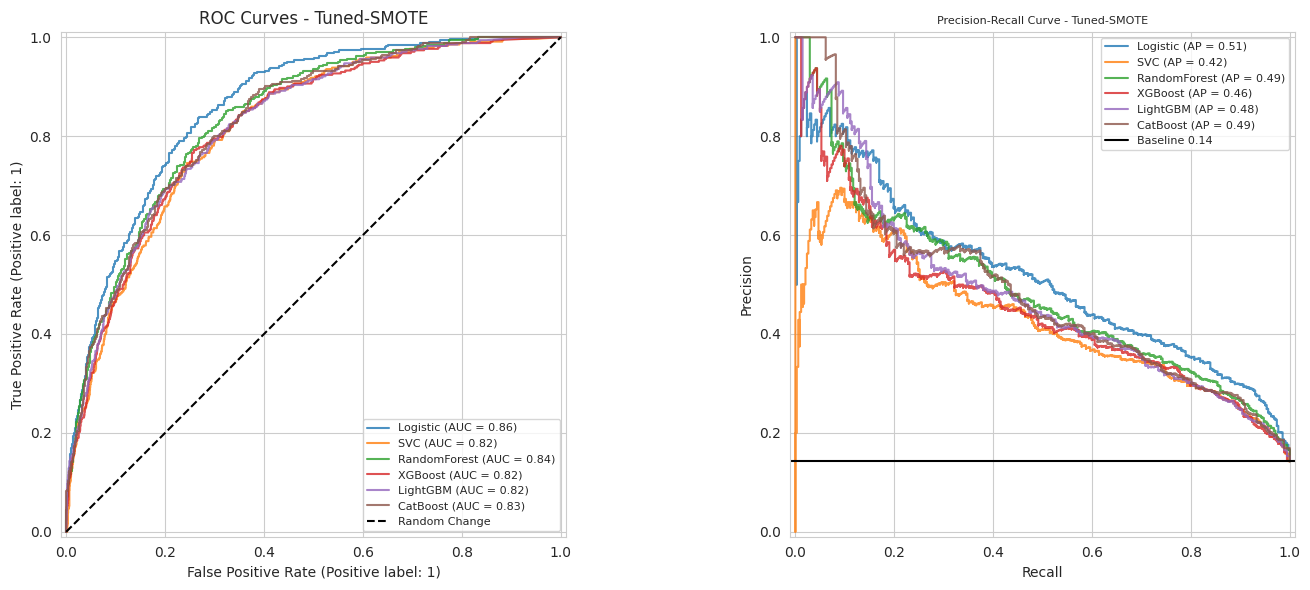

In [ ]:
plot_model_comparison(predictions, 'Tuned-SMOTE')

### models with class weight adjustment

In [ ]:
count_neg = (y_train == 0).sum()
count_pos = (y_train == 1).sum()
scale_weight = (count_neg / count_pos).item()

In [ ]:
models_weight = {
    'Logistic': LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000, random_state=SEED),
    'SVC': SVC(class_weight='balanced', C=0.1, probability=True, kernel='rbf', random_state=SEED, cache_size=1000),
    'RandomForest': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=200, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='aucpr', scale_pos_weight=scale_weight, random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(objective='binary', is_unbalance=True, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1),
    'CatBoost': CatBoostClassifier(loss_function='Logloss', eval_metric='Recall', auto_class_weights='Balanced', random_state=SEED, verbose=0)}

In [ ]:
for name, model in models_weight.items():
  if name in ['Logistic', 'SVC']:
    evaluate_model(name, 'Weight', model, X_train_linear, X_test_linear, y_train, y_test)
  else:
    evaluate_model(name, 'Weight', model, X_train_tree, X_test_tree, y_train, y_test)

Fitting Logistic...
Output metrics for Logistic...
Output feature importance for Logistic...
Fitting SVC...
Output metrics for SVC...
Output feature importance for SVC...
Fitting RandomForest...
Output metrics for RandomForest...
Output feature importance for RandomForest...
Fitting XGBoost...
Output metrics for XGBoost...
Output feature importance for XGBoost...
Fitting LightGBM...
Output metrics for LightGBM...
Output feature importance for LightGBM...
Fitting CatBoost...
Output metrics for CatBoost...
Output feature importance for CatBoost...


In [ ]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863310,0.513641,0.514620,0.771930,0.385965,0.795720,0.792327,264,1636,420,78
1,SVC,SMOTE,0.832394,0.416772,0.480749,0.675439,0.373183,0.811284,0.791910,231,1668,388,111
2,RandomForest,SMOTE,0.842863,0.468563,0.477124,0.426901,0.540741,0.939689,0.866555,146,1932,124,196
3,XGBoost,SMOTE,0.852555,0.517836,0.447552,0.374269,0.556522,0.950389,0.868224,128,1954,102,214
4,LightGBM,SMOTE,0.857578,0.505905,0.458844,0.383041,0.572052,0.952335,0.871143,131,1958,98,211
5,CatBoost,SMOTE,0.868124,0.549402,0.454383,0.371345,0.585253,0.956226,0.872811,127,1966,90,215
6,Logistic,Tuned-SMOTE,0.859434,0.513692,0.490532,0.795322,0.354628,0.759241,0.764387,272,1561,495,70
7,SVC,Tuned-SMOTE,0.818391,0.423881,0.389381,0.321637,0.493274,0.945039,0.856130,110,1943,113,232
8,RandomForest,Tuned-SMOTE,0.837715,0.488019,0.478022,0.508772,0.450777,0.896887,0.841535,174,1844,212,168
9,XGBoost,Tuned-SMOTE,0.820981,0.455618,0.452221,0.491228,0.418953,0.886673,0.830275,168,1823,233,174



--- Plotting Curves for Strategy: Weight ---



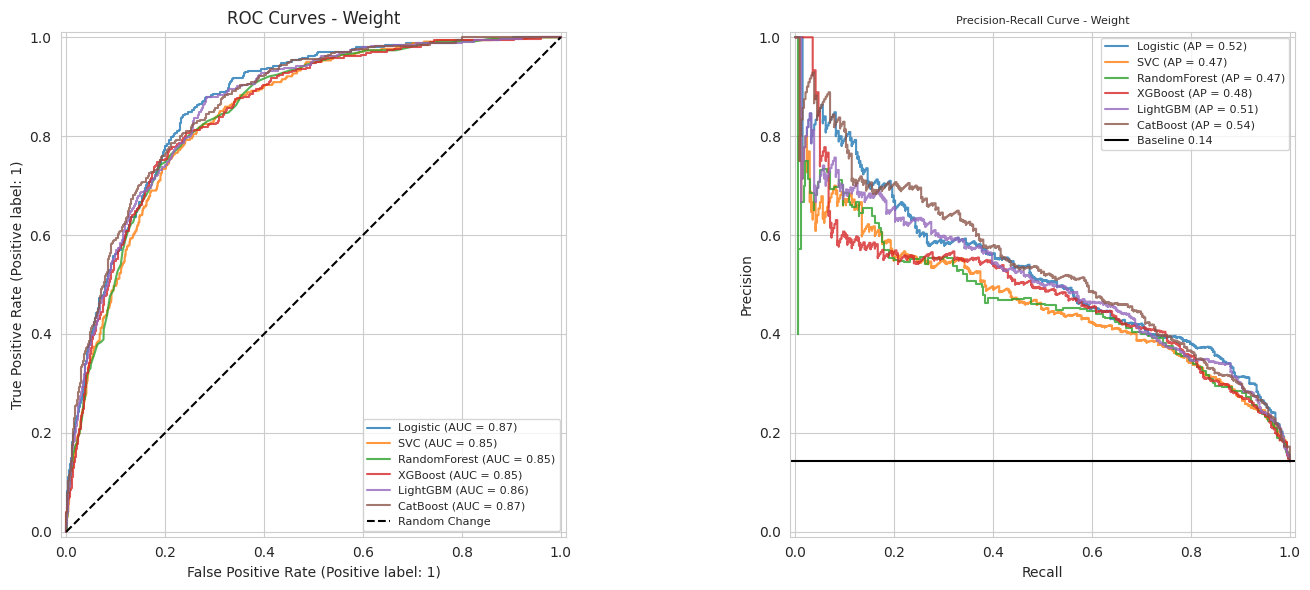

In [ ]:
plot_model_comparison(predictions, 'Weight')

### models with class weight adjustment after hyperparameter tuning

In [ ]:
param_grids = {
    'Logistic': {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    'SVC': {'C': [0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto', 0.001, 0.01], 'kernel': ['rbf', 'sigmoid']},
    'RandomForest': {'n_estimators': [100, 200, 300, 500], 'max_depth': [8, 12, 16, 20, None], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']},
    'XGBoost': {'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7, 9], 'min_child_weight': [1, 3, 5], 'n_estimators': [100, 200, 500]},
    'LightGBM': {'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [31, 63, 127], 'n_estimators': [100, 200, 500], 'feature_fraction': [0.7, 0.8, 0.9]},
    'CatBoost': {'depth': [4, 6, 8, 10], 'learning_rate': [0.01, 0.05, 0.1], 'iterations': [100, 200, 500], 'l2_leaf_reg': [1, 3, 5, 9]}}

In [ ]:
for name, model in models_weight.items():
  if name in ['Logistic', 'SVC']:
    best_model = tune_model(name, model, param_grids, X_train_linear, y_train, search_type='random', cv=5, n_iter=10, scoring='recall')
    best_models_smote[name] = best_model
    evaluate_model(name, 'Tuned-Weight', best_model, X_train_linear, X_test_linear, y_train, y_test, is_tuned=True)
  else:
    best_model = tune_model(name, model, param_grids, X_train_tree, y_train, search_type='random', cv=5, n_iter=10, scoring='recall')
    best_models_smote[name] = best_model
    evaluate_model(name, 'Tuned-Weight', best_model, X_train_tree, X_test_tree, y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Logistic tuned. Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.001}

Using pre-fitted tuned model for Logistic...
Output metrics for Logistic...
Output feature importance for Logistic...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

SVC tuned. Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.01}

Using pre-fitted tuned model for SVC...
Output metrics for SVC...
Output feature importance for SVC...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

RandomForest tuned. Best Parameters: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 8}

Using pre-fitted tuned model for RandomForest...
Output metrics for RandomForest...
Output feature importance for RandomForest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

XGBoost tuned. Best Parameters: {'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01}

/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



CatBoost tuned. Best Parameters: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 4}

Using pre-fitted tuned model for CatBoost...
Output metrics for CatBoost...
Output feature importance for CatBoost...


In [ ]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863310,0.513641,0.514620,0.771930,0.385965,0.795720,0.792327,264,1636,420,78
1,SVC,SMOTE,0.832394,0.416772,0.480749,0.675439,0.373183,0.811284,0.791910,231,1668,388,111
2,RandomForest,SMOTE,0.842863,0.468563,0.477124,0.426901,0.540741,0.939689,0.866555,146,1932,124,196
3,XGBoost,SMOTE,0.852555,0.517836,0.447552,0.374269,0.556522,0.950389,0.868224,128,1954,102,214
4,LightGBM,SMOTE,0.857578,0.505905,0.458844,0.383041,0.572052,0.952335,0.871143,131,1958,98,211
5,CatBoost,SMOTE,0.868124,0.549402,0.454383,0.371345,0.585253,0.956226,0.872811,127,1966,90,215
6,Logistic,Tuned-SMOTE,0.859434,0.513692,0.490532,0.795322,0.354628,0.759241,0.764387,272,1561,495,70
7,SVC,Tuned-SMOTE,0.818391,0.423881,0.389381,0.321637,0.493274,0.945039,0.856130,110,1943,113,232
8,RandomForest,Tuned-SMOTE,0.837715,0.488019,0.478022,0.508772,0.450777,0.896887,0.841535,174,1844,212,168
9,XGBoost,Tuned-SMOTE,0.820981,0.455618,0.452221,0.491228,0.418953,0.886673,0.830275,168,1823,233,174



--- Plotting Curves for Strategy: Tuned-Weight ---



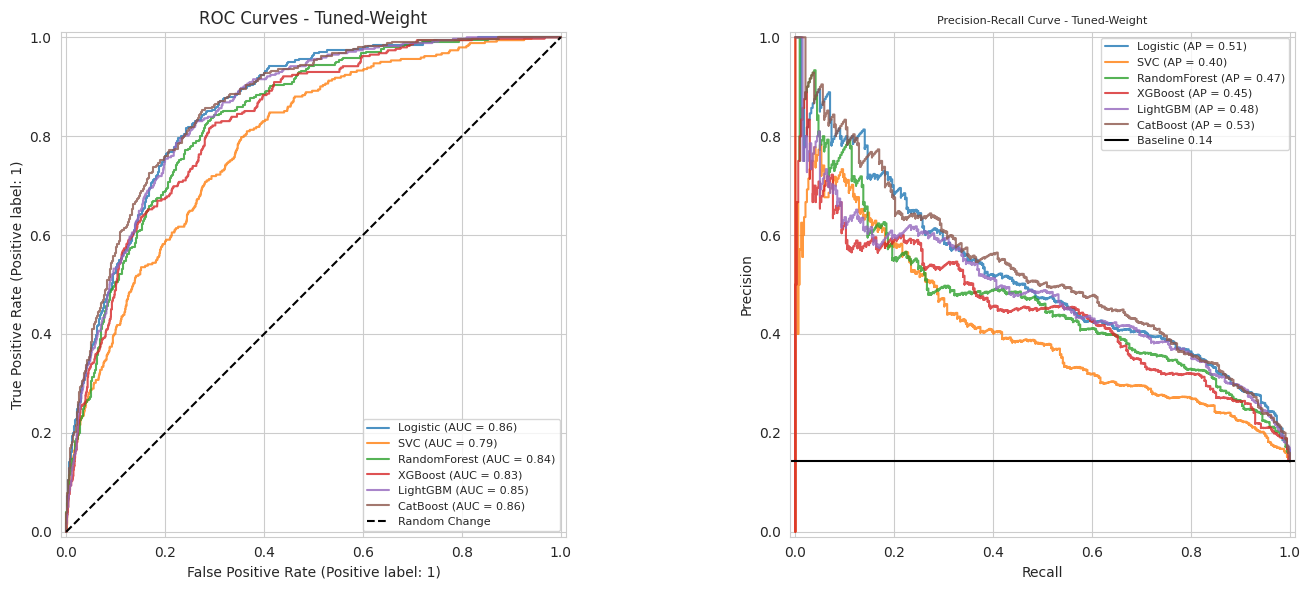

In [ ]:
plot_model_comparison(predictions, 'Tuned-Weight')

# feature importance

In [ ]:
df_all_importance = pd.concat(dfs_importance).reset_index(drop=True)

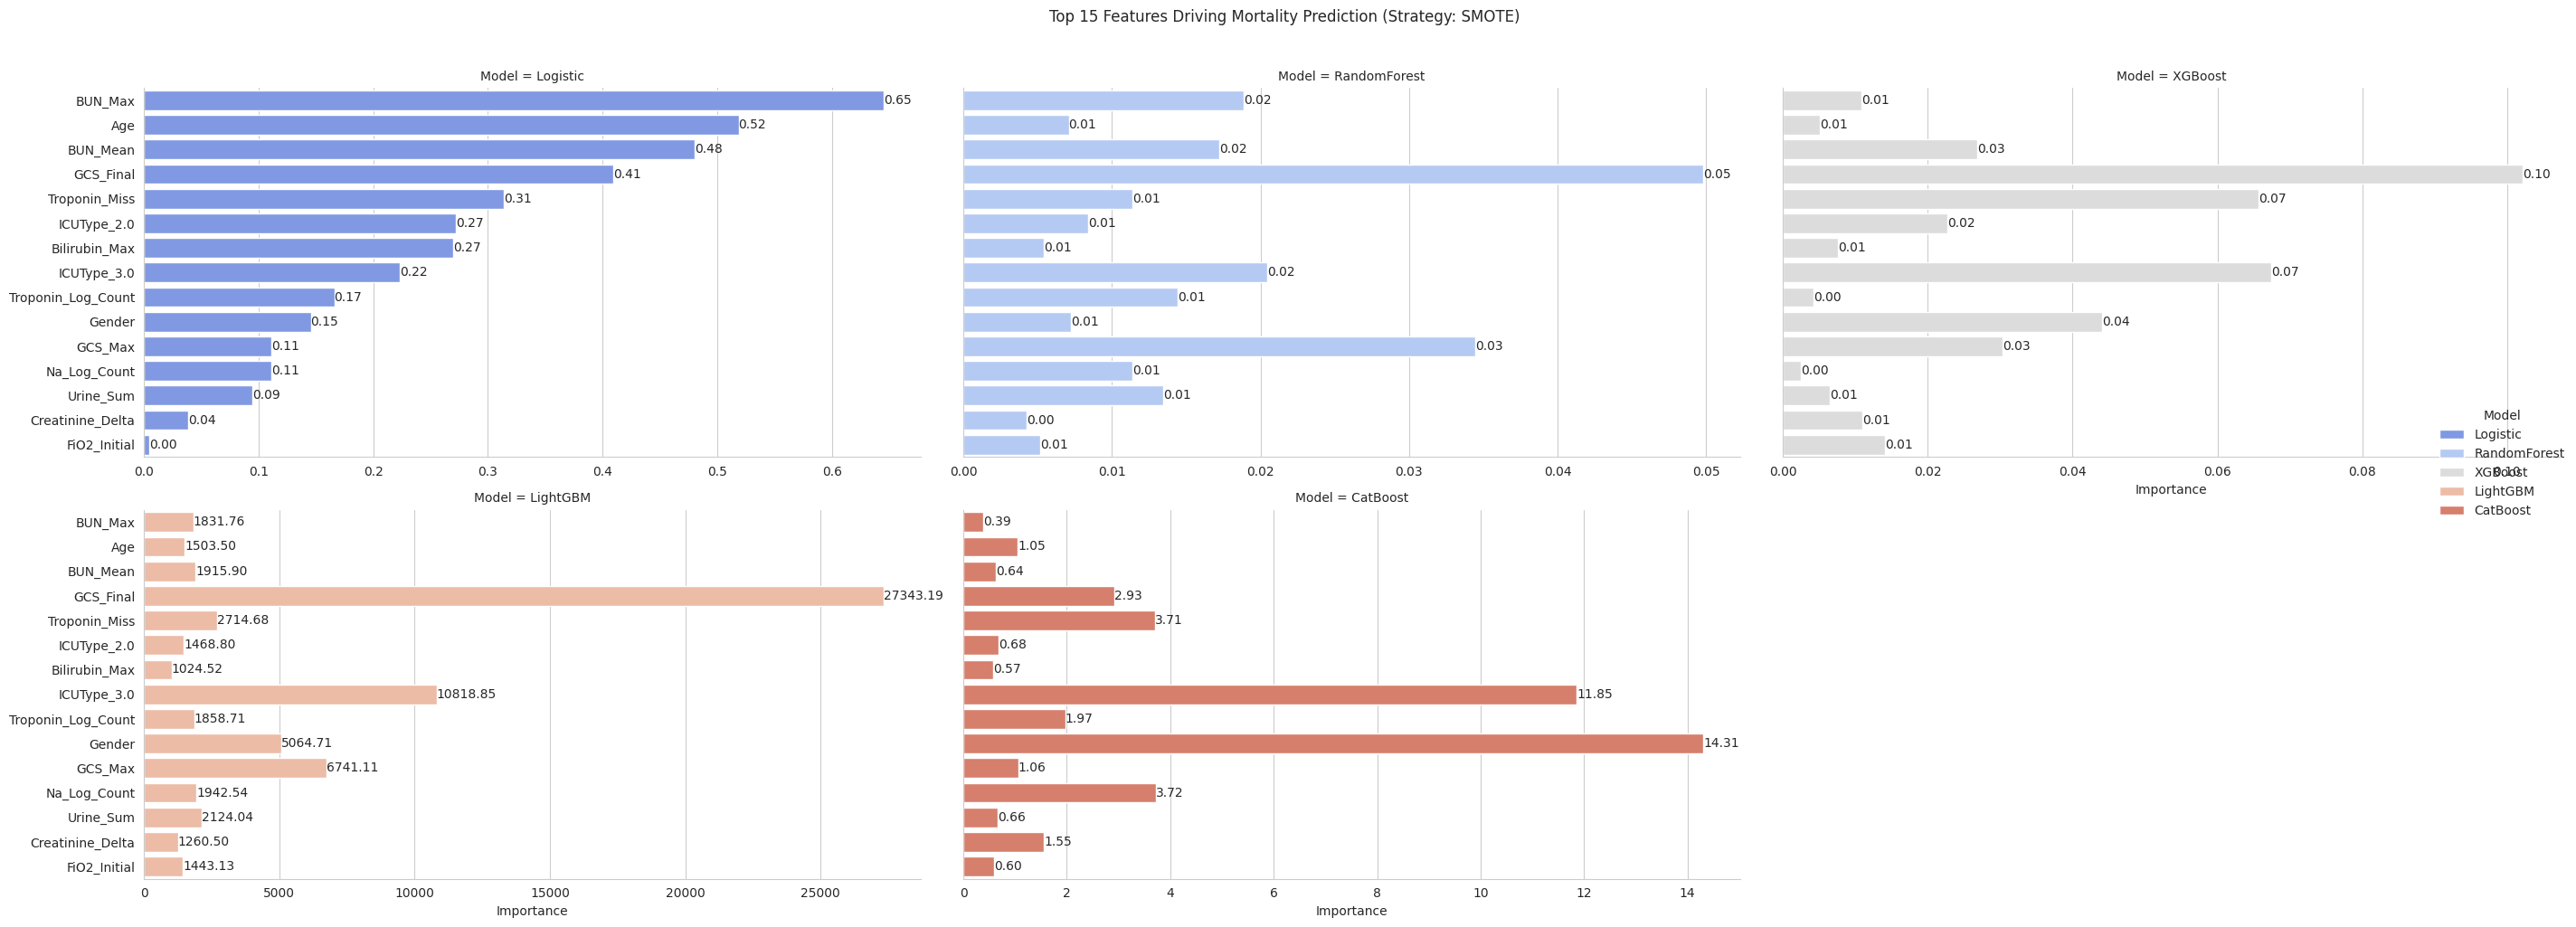

In [ ]:
plot_feature_comparison(df_all_importance, 'SMOTE', top_n=15)

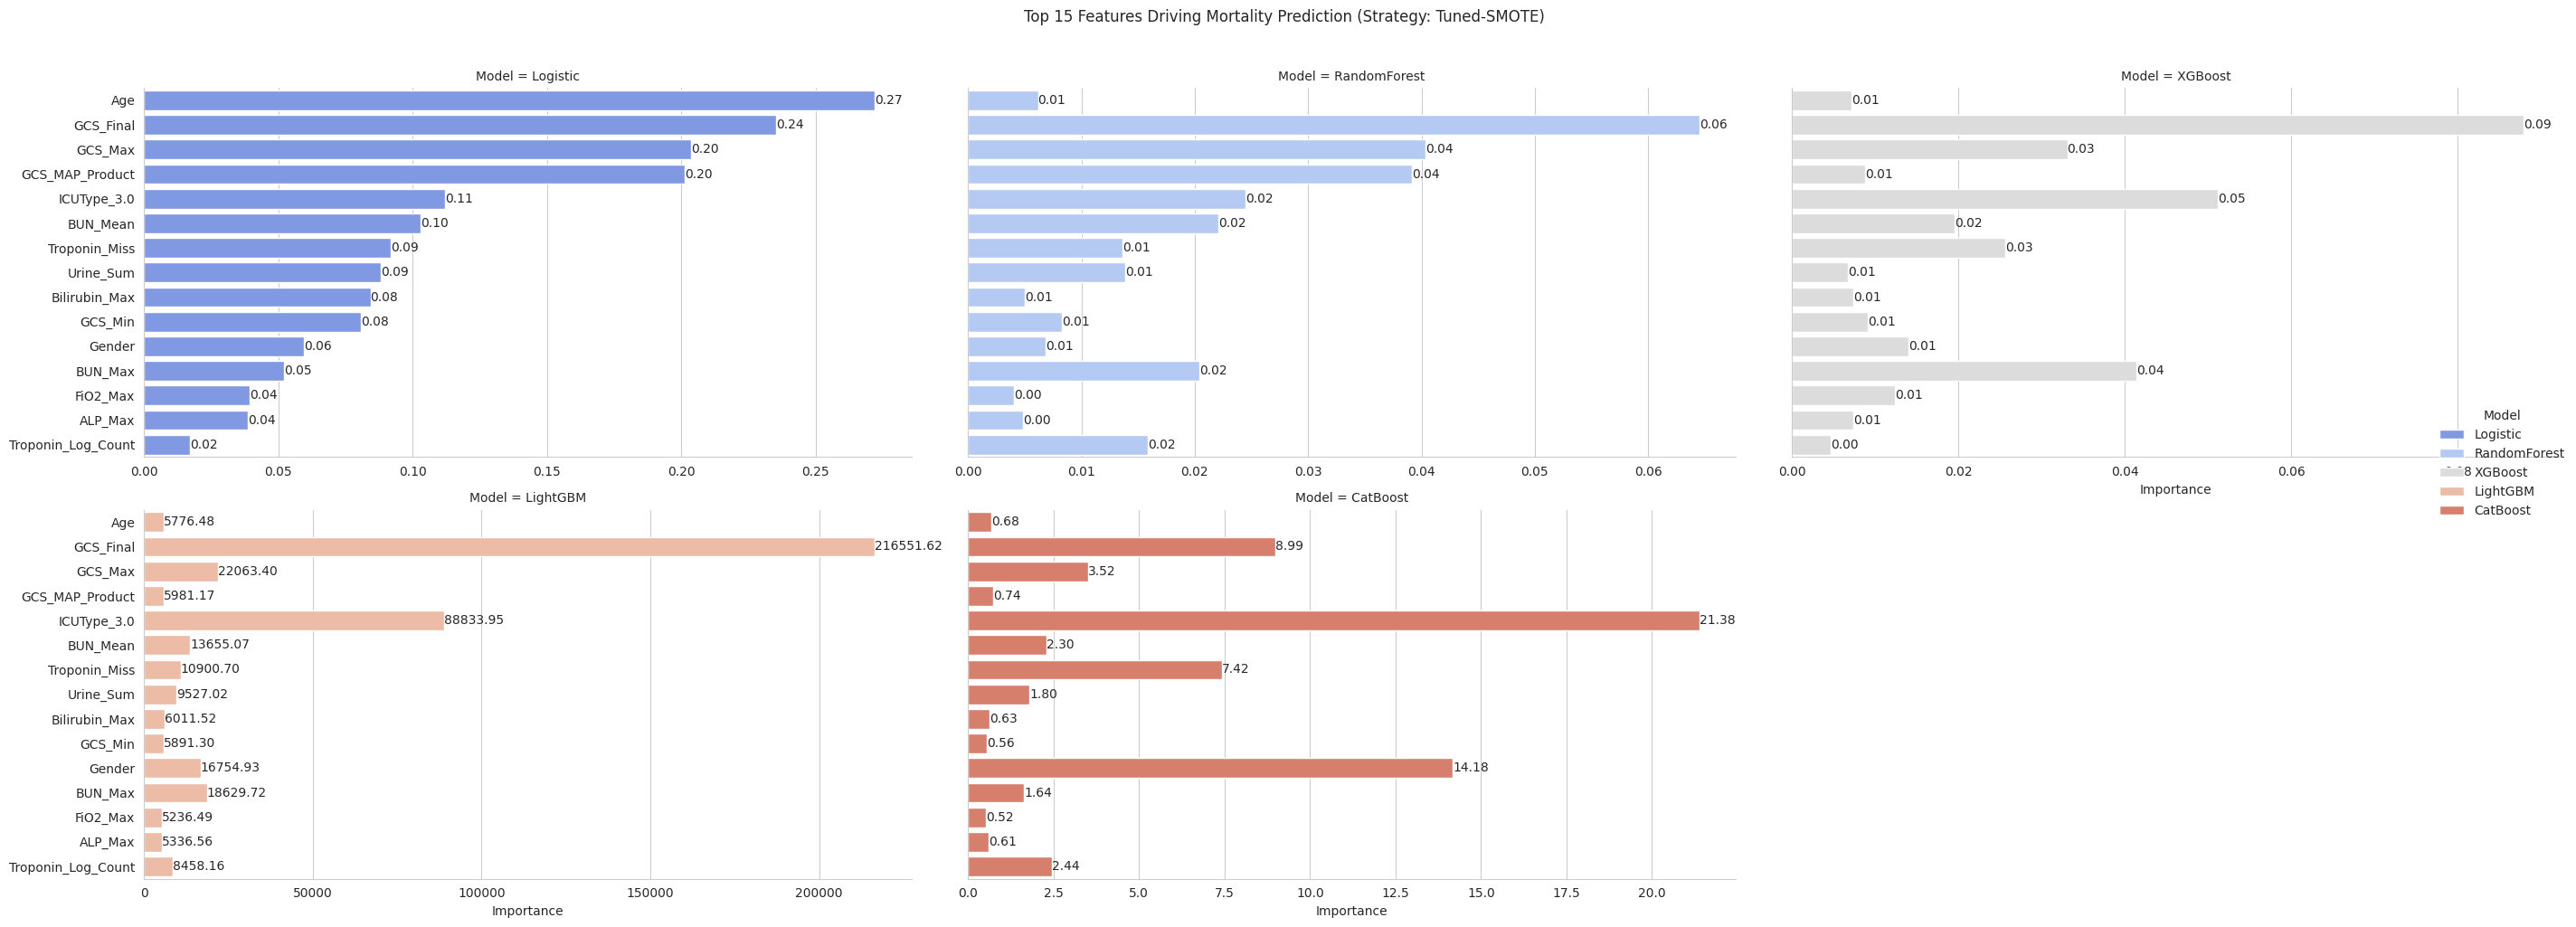

In [ ]:
plot_feature_comparison(df_all_importance, 'Tuned-SMOTE', top_n=15)

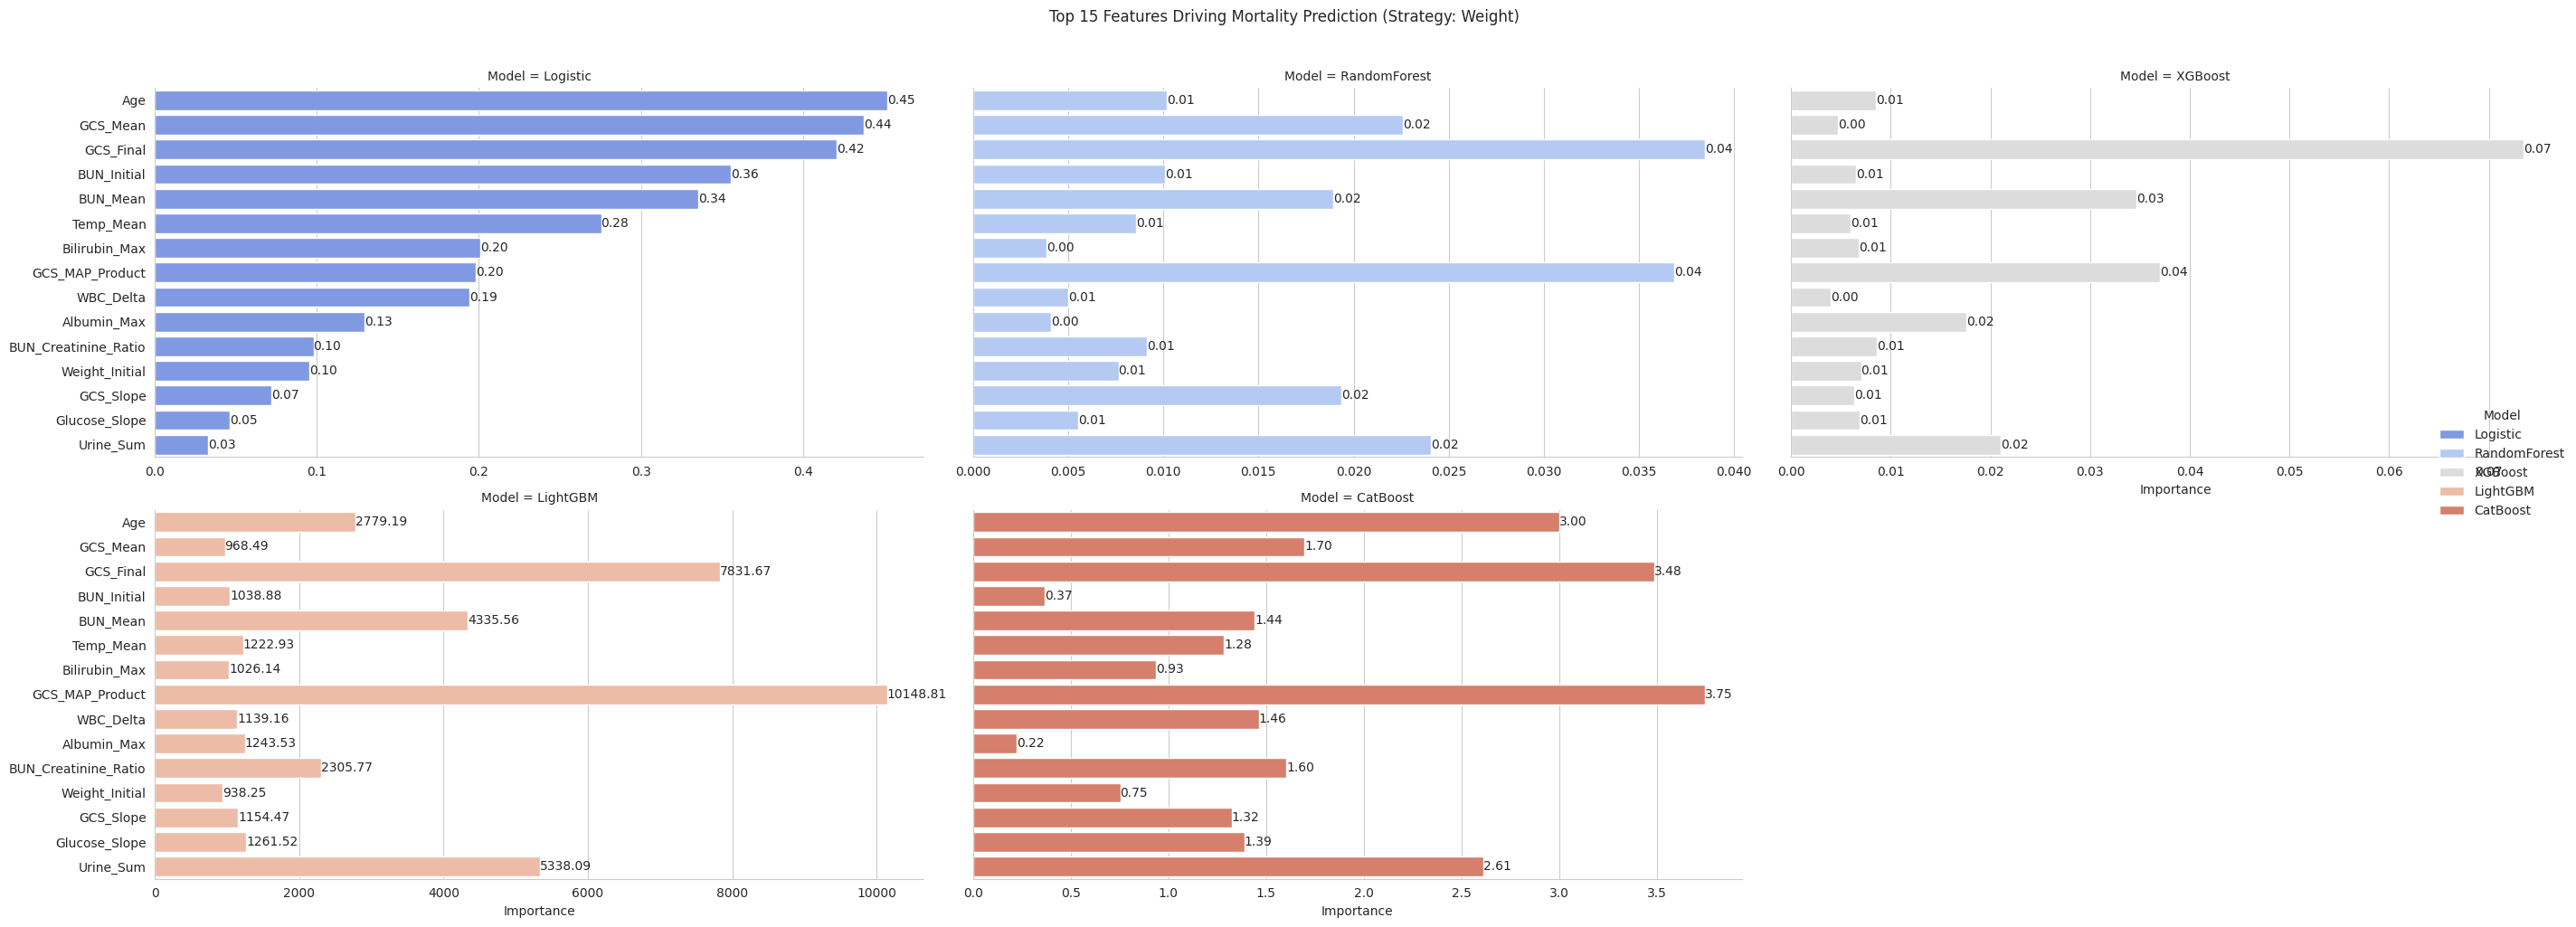

In [ ]:
plot_feature_comparison(df_all_importance, 'Weight', top_n=15)

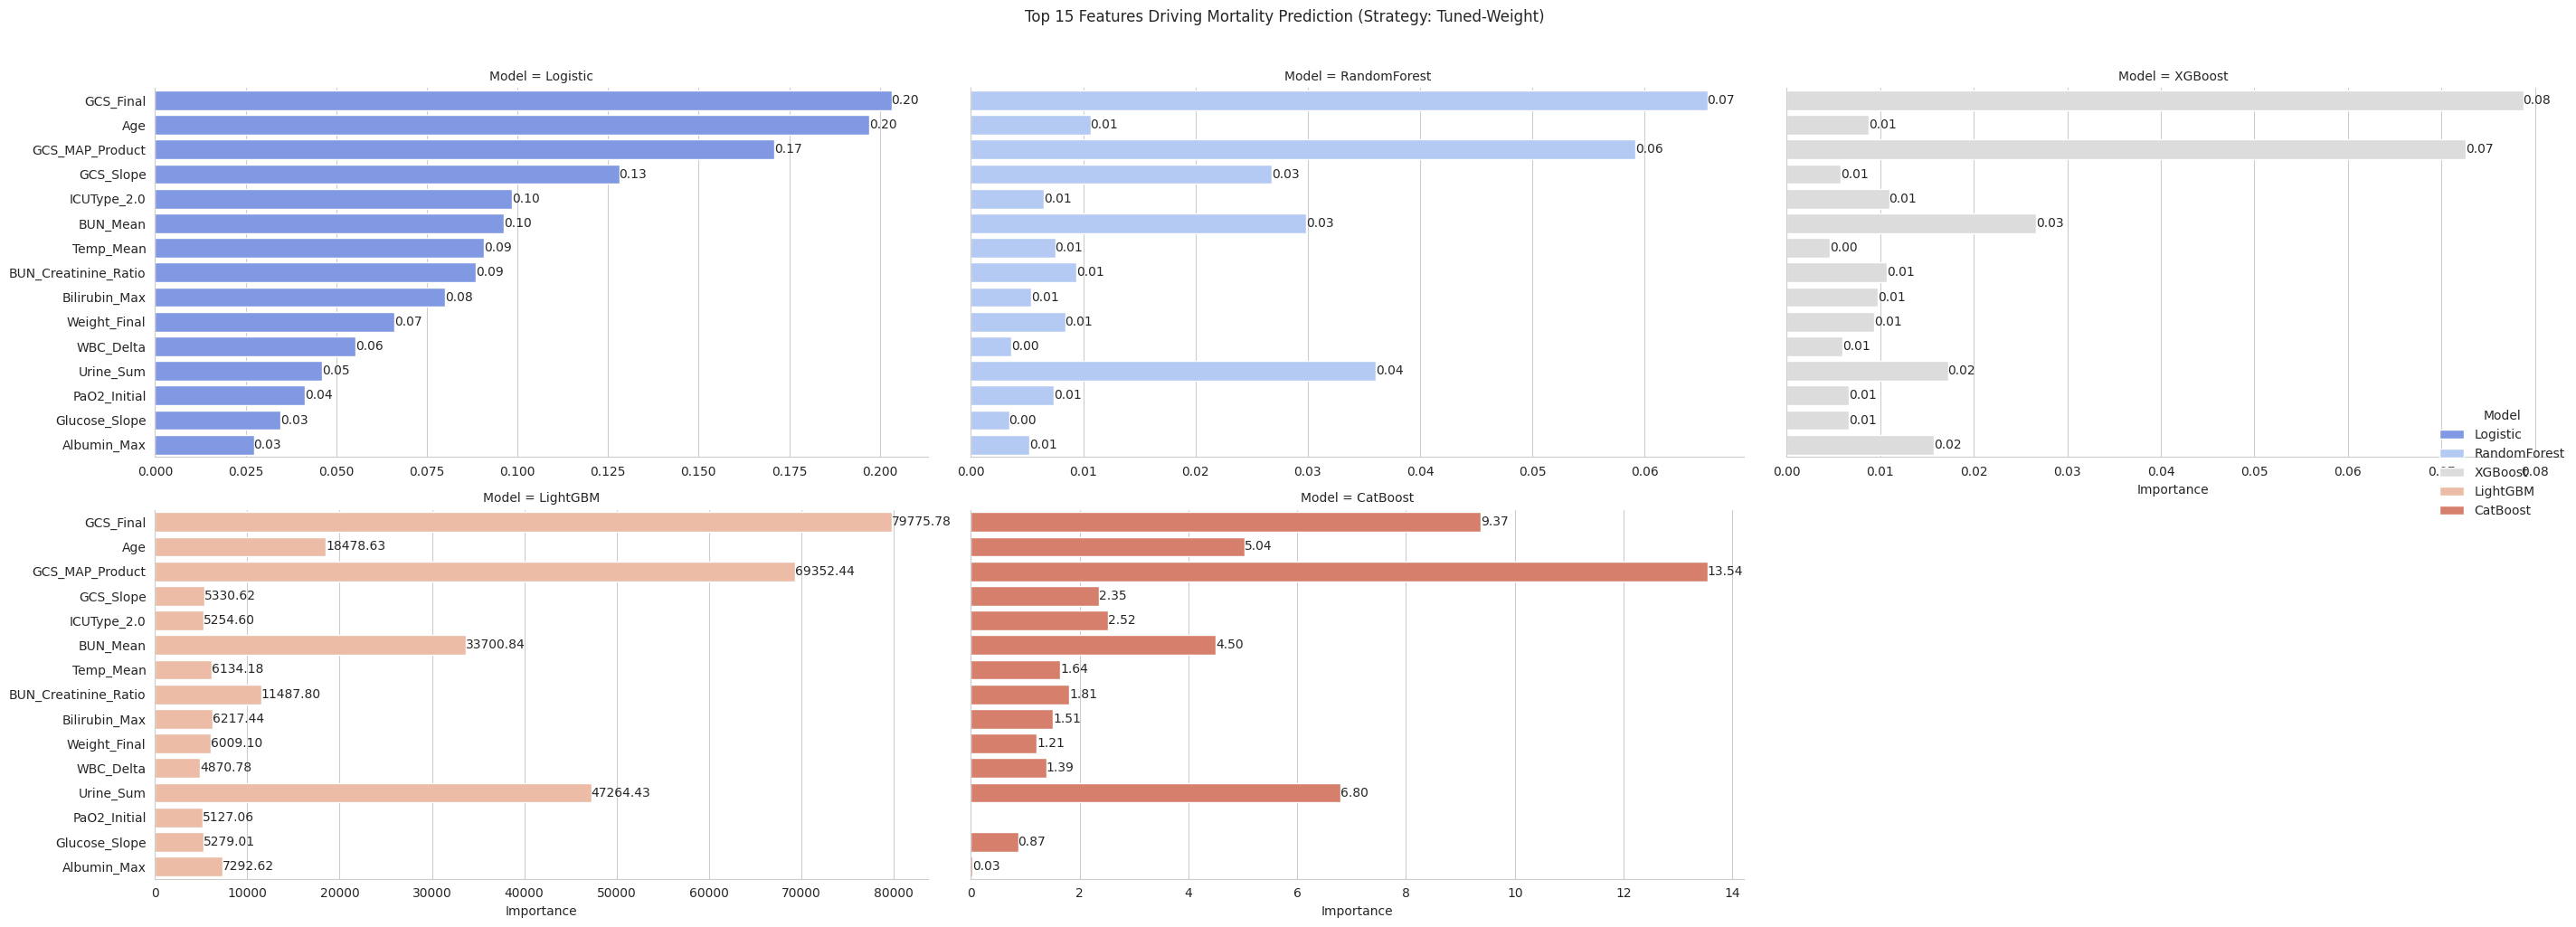

In [ ]:
plot_feature_comparison(df_all_importance, 'Tuned-Weight', top_n=15)

# feature selection

### protected features

In [ ]:
#X_train_tree.columns.to_list()

In [ ]:
#X_train_linear.columns.to_list()

In [ ]:
protected_features = ['Age', 'GCS_Min', 'Lactate_Max', 'Urine_Sum', 'Anion_Gap', 'Shock_Index', 'UniMAP_Min', 'PaO2_FiO2_Ratio', 'Creatinine_Max', 'pH_Min']

### correlation to select features

In [ ]:
corr_matrix = X_train_smote.corr().abs()

In [ ]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [ ]:
to_drop = []
threshold = 0.9

for col in upper.columns:
  if any(upper[col] > threshold):
    if col in protected_features:
      continue
    to_drop.append(col)

In [ ]:
#to_drop

In [ ]:
X_train_tree_p = X_train_tree.drop(columns=to_drop)

In [ ]:
X_test_tree_p = X_test_tree.drop(columns=to_drop)

In [ ]:
X_train_linear_p = X_train_linear.drop(columns=to_drop)

In [ ]:
X_test_linear_p = X_test_linear.drop(columns=to_drop)

In [ ]:
X_train_tree_p.shape, X_test_tree_p.shape, X_train_linear_p.shape, X_test_linear_p.shape

((9588, 186), (2398, 186), (9588, 186), (2398, 186))

### feature importance to select features

In [ ]:
model_cb = CatBoostClassifier(loss_function='Logloss', eval_metric='Recall', auto_class_weights='Balanced', random_state=SEED, verbose=0, learning_rate=0.05, l2_leaf_reg=5, iterations=200, depth=4)
classifier_cb = model_cb.fit(X_train_tree_p, y_train)
imp_cb = pd.Series(classifier_cb.get_feature_importance(), index=X_train_tree_p.columns)

In [ ]:
imp_cb

Albumin_Initial               5.812821e-02
ALP_Initial                   1.473919e+00
ALT_Initial                   6.760797e-02
ALT_Max                       3.707288e-02
AST_Initial                   1.854278e-02
Bilirubin_Initial             1.756053e+00
BUN_Initial                   3.881646e+00
BUN_Creatinine_Ratio          3.066046e+00
Cholesterol_Initial           0.000000e+00
Creatinine_Initial            1.383586e-01
Creatinine_Max                8.932578e-01
FiO2_Initial                  8.176677e-02
FiO2_Max                      4.627738e-01
FiO2_Mean                     5.494436e-01
GCS_Initial                   3.693889e-01
GCS_Final                     1.270137e+01
GCS_Min                       2.066779e-01
GCS_Max                       1.570295e+00
GCS_Mean                      1.975973e+00
Glucose_Initial               1.379594e-01
Glucose_Min                   1.081532e-03
Glucose_Max                   2.218733e-01
Glucose_Mean                  7.217177e-01
HCO3_Initia

In [ ]:
model_lgb = LGBMClassifier(objective='binary', is_unbalance=True, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1)
classifier_lgb = model_lgb.fit(X_train_tree_p, y_train)
imp_lgb = pd.Series(classifier_lgb.feature_importances_, index=X_train_tree_p.columns)

In [ ]:
imp_lgb

Albumin_Initial                1289.164477
ALP_Initial                     884.144567
ALT_Initial                     153.466450
ALT_Max                         175.618698
AST_Initial                     415.013432
Bilirubin_Initial              1178.012034
BUN_Initial                    2631.813884
BUN_Creatinine_Ratio           2707.497372
Cholesterol_Initial              39.230100
Creatinine_Initial              368.752401
Creatinine_Max                  740.719810
FiO2_Initial                     96.666240
FiO2_Max                         96.255370
FiO2_Mean                       590.226790
GCS_Initial                     245.993589
GCS_Final                      7525.642030
GCS_Min                         544.298098
GCS_Max                         470.240228
GCS_Mean                        888.162361
Glucose_Initial                 474.784364
Glucose_Min                     299.614300
Glucose_Max                     520.848551
Glucose_Mean                    638.557388
HCO3_Initia

In [ ]:
model_lr = LogisticRegression(class_weight='balanced', solver='liblinear', penalty='l2', C=0.001, max_iter=1000, random_state=SEED)
classifier_lr = model_lr.fit(X_train_linear_p, y_train)
imp_lr = pd.Series(classifier_lr.coef_[0], index=X_train_linear_p.columns)

In [ ]:
imp_lr

Albumin_Initial              -0.062734
ALP_Initial                   0.083361
ALT_Initial                  -0.000315
ALT_Max                      -0.008160
AST_Initial                   0.015849
Bilirubin_Initial             0.131843
BUN_Initial                   0.146399
BUN_Creatinine_Ratio          0.113900
Cholesterol_Initial          -0.010522
Creatinine_Initial            0.014368
Creatinine_Max                0.005740
FiO2_Initial                 -0.014194
FiO2_Max                      0.008132
FiO2_Mean                     0.060517
GCS_Initial                   0.039265
GCS_Final                    -0.208279
GCS_Min                       0.037398
GCS_Max                      -0.175985
GCS_Mean                     -0.150268
Glucose_Initial              -0.031452
Glucose_Min                   0.027157
Glucose_Max                   0.008725
Glucose_Mean                  0.052333
HCO3_Initial                  0.007747
HCO3_Final                   -0.055201
HCT_Initial              

In [ ]:
def get_top_features(importance_series, protected_features, top_n=70):

  sorted_importance = importance_series.sort_values(ascending=False).index.to_list()
  final_list = [f for f in protected_features if f in sorted_importance]

  for f in sorted_importance:
    if len(final_list) >= top_n:
      break
    if f not in final_list:
      final_list.append(f)

  return final_list

In [ ]:
final_cb = get_top_features(imp_cb, protected_features)
final_lgb = get_top_features(imp_lgb, protected_features)
final_lr = get_top_features(imp_lr, protected_features)

In [ ]:
common = set(final_cb) & set(final_lgb) & set(final_lr)
common

{'ALP_Initial',
 'Age',
 'Anion_Gap',
 'BUN_Creatinine_Ratio',
 'BUN_Delta',
 'BUN_Initial',
 'Bilirubin_Delta',
 'Bilirubin_Initial',
 'Creatinine_Delta',
 'Creatinine_Max',
 'FiO2_Mean',
 'FiO2_Slope',
 'GCS_Last_Gap',
 'GCS_Log_Count',
 'GCS_Min',
 'Glucose_Mean',
 'Glucose_Slope',
 'HCT_Delta',
 'HR_Final',
 'HR_SD',
 'Lactate_Max',
 'Mg_Delta',
 'Na_Delta',
 'PaO2_FiO2_Ratio',
 'RespRate_Initial',
 'RespRate_Mean',
 'Shock_Index',
 'Temp_SD',
 'UniMAP_Min',
 'UniSysABP_Mean',
 'Urine_Sum',
 'WBC_Delta',
 'pH_Max',
 'pH_Mean',
 'pH_Min'}

In [ ]:
len(common)

35

# hyperparameter tuning

In [ ]:
params_cb = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10],
    'iterations': [100, 200, 500, 1000]
}

rs_cb = RandomizedSearchCV(
    CatBoostClassifier(loss_function='Logloss', eval_metric='Recall', auto_class_weights='Balanced', random_state=SEED, verbose=0),
    param_distributions=params_cb, n_iter=10, cv=5, scoring='recall', n_jobs=-1, verbose=1, random_state=SEED
)


rs_cb.fit(X_train_tree[final_cb], y_train)
best_cb = rs_cb.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
params_lgb ={
    'num_leaves': [31, 63, 127],
    'max_depth': [6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500, 1000],
    'min_child_samples': [20, 50],
    'feature_fraction': [0.7, 0.8, 0.9]
}

rs_lgb = RandomizedSearchCV(
    LGBMClassifier(objective='binary', is_unbalance=True, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1),
    param_distributions=params_lgb, n_iter=10, cv=5, scoring='recall', n_jobs=-1, verbose=1, random_state=SEED
)

rs_lgb.fit(X_train_tree[final_lgb], y_train)
best_lgb = rs_lgb.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
params_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

gs_lr = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000, random_state=SEED),
    param_distributions=params_lr, n_iter=10, cv=5, scoring='recall', n_jobs=-1, verbose=1, random_state=SEED
)

gs_lr.fit(X_train_linear[final_lr], y_train)
best_lr = gs_lr.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


# probability calibration

In [ ]:
cal_cb = CalibratedClassifierCV(best_cb, method='sigmoid', cv=5)
cal_lgb = CalibratedClassifierCV(best_lgb, method='sigmoid', cv=5)
cal_lr = CalibratedClassifierCV(best_lr, method='sigmoid', cv=5)

In [ ]:
cal_cb.fit(X_train_tree[final_cb], y_train)

,estimator,<catboost.cor...x7f972c124bb0>
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'


In [ ]:
cal_lgb.fit(X_train_tree[final_lgb], y_train)

,estimator,"LGBMClassifie...2, verbose=-1)"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000


In [ ]:
cal_lr.fit(X_train_linear[final_lr], y_train)

,estimator,LogisticRegre...r='liblinear')
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1


# ensemble model

In [ ]:
prob_lr = cal_lr.predict_proba(X_test_linear[final_lr])[:, 1]
prob_cb  = cal_cb.predict_proba(X_test_tree[final_cb])[:, 1]
prob_lgb = cal_lgb.predict_proba(X_test_tree[final_lgb])[:, 1]

In [ ]:
w_cb, w_lgb, w_lr = 0.50, 0.35, 0.15

In [ ]:
weighted_ensemble_probs = (w_cb * prob_cb) + (w_lgb * prob_lgb) + (w_lr * prob_lr)

In [ ]:
best_pr = 0
best_weights = (0, 0, 0)

for w_cb in np.linspace(0.1, 0.5, 9):
    for w_lgb in np.linspace(0.1, 0.5, 9):
        w_lr = 1.0 - w_cb - w_lgb
        if w_lr < 0.2: continue

        ensemble_probs = (w_cb * prob_cb) + (w_lgb * prob_lgb) + (w_lr * prob_lr)
        score = average_precision_score(y_test, ensemble_probs)

        if score > best_pr:
            best_pr = score
            best_roc = roc_auc_score(y_test, ensemble_probs)
            best_weights = (round(w_cb, 2), round(w_lgb, 2), round(w_lr, 2))

print(f'{best_pr: .4f}')
print(best_weights)

 0.5412
(np.float64(0.25), np.float64(0.5), np.float64(0.25))


# threshold optimization

In [ ]:
w_cb, w_lgb, w_lr = best_weights
final_prob = (w_cb * prob_cb) + (w_lgb * prob_lgb) + (w_lr * prob_lr)

In [ ]:
best_recall = 0
best_precision = 0
best_threshold = 0
ensemble_metrics = {}

for threshold in np.linspace(0.2, 0.6, 200):
    preds = (final_prob >= threshold).astype(int)
    rec = recall_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)

    if prec >= 0.30:

        if rec > best_recall or (rec == best_recall) and (prec > best_precision):
            best_recall = rec
            best_precision = prec
            best_threshold = threshold

            tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
            best_recall = rec
            best_precision = prec
            ensemble_metrics = {
                'Model': 'Ensemble',
                'Strategy': 'Weighted_Optimized',
                'ROC_AUC': roc_auc_score(y_test, final_prob),
                'PR_AUC': best_pr,
                'F1': f1_score(y_test, preds),
                'Recall': rec,
                'Precision': prec,
                'Specificity': tn / (tn + fp),
                'Accuracy': accuracy_score(y_test, preds),
                'TP': tp,
                'TN': tn,
                'FP': fp,
                'FN': fn
            }

print(f'--- Final Optimized Ensemble Result ---')
for k, v in ensemble_metrics.items():
    print(f'{k}: {v}')

--- Final Optimized Ensemble Result ---
Model: Ensemble
Strategy: Weighted_Optimized
ROC_AUC: 0.8691563132864587
PR_AUC: 0.5412253285232331
F1: 0.5330347144456887
Recall: 0.695906432748538
Precision: 0.4319419237749546
Specificity: 0.8477626459143969
Accuracy: 0.8261050875729775
TP: 238
TN: 1743
FP: 313
FN: 104


# final result

### result table

In [ ]:
results.append({
    'Model': ensemble_metrics['Model'], 'Strategy': ensemble_metrics['Strategy'], 'ROC_AUC': ensemble_metrics['ROC_AUC'], 'PR_AUC': ensemble_metrics['PR_AUC'],
    'F1': ensemble_metrics['F1'], 'Recall': ensemble_metrics['Recall'], 'Precision': ensemble_metrics['Precision'],
    'Specificity': ensemble_metrics['Specificity'], 'Accuracy': ensemble_metrics['Accuracy'],
    'TP': ensemble_metrics['TP'], 'TN': ensemble_metrics['TN'], 'FP': ensemble_metrics['FP'], 'FN': ensemble_metrics['FN']
})

keys = ensemble_metrics['Model']+'_'+ensemble_metrics['Strategy']
predictions[keys] = (y_test, final_prob)

In [ ]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863310,0.513641,0.514620,0.771930,0.385965,0.795720,0.792327,264,1636,420,78
1,SVC,SMOTE,0.832394,0.416772,0.480749,0.675439,0.373183,0.811284,0.791910,231,1668,388,111
2,RandomForest,SMOTE,0.842863,0.468563,0.477124,0.426901,0.540741,0.939689,0.866555,146,1932,124,196
3,XGBoost,SMOTE,0.852555,0.517836,0.447552,0.374269,0.556522,0.950389,0.868224,128,1954,102,214
4,LightGBM,SMOTE,0.857578,0.505905,0.458844,0.383041,0.572052,0.952335,0.871143,131,1958,98,211
5,CatBoost,SMOTE,0.868124,0.549402,0.454383,0.371345,0.585253,0.956226,0.872811,127,1966,90,215
6,Logistic,Tuned-SMOTE,0.859434,0.513692,0.490532,0.795322,0.354628,0.759241,0.764387,272,1561,495,70
7,SVC,Tuned-SMOTE,0.818391,0.423881,0.389381,0.321637,0.493274,0.945039,0.856130,110,1943,113,232
8,RandomForest,Tuned-SMOTE,0.837715,0.488019,0.478022,0.508772,0.450777,0.896887,0.841535,174,1844,212,168
9,XGBoost,Tuned-SMOTE,0.820981,0.455618,0.452221,0.491228,0.418953,0.886673,0.830275,168,1823,233,174


### confusion matrix, ROC curve, PR curve, feature importance

In [ ]:
def get_ensemble_importance(X_cb, X_lgb, X_lr, y_test, weights, n_repeats=5):

    w_cb, w_lgb, w_lr = weights

    def predict_ensemble(dat_cb, dat_lgb, dat_lr):
        p_cb = best_cb.predict_proba(dat_cb)[:, 1]
        p_lgb = best_lgb.predict_proba(dat_lgb)[:, 1]
        p_lr = best_lr.predict_proba(dat_lr)[:, 1]
        return (w_cb * p_cb) + (w_lgb * p_lgb) + (w_lr * p_lr)

    baseline_auc = roc_auc_score(y_test, predict_ensemble(X_cb, X_lgb, X_lr))
    importances = []

    print("Calculating Synchronized Feature Importance (Permutation)...")

    for col in X_cb.columns:
        scores = []
        for _ in range(n_repeats):
            X_cb_perm = X_cb.copy()
            X_lgb_perm = X_lgb.copy()
            X_lr_perm = X_lr.copy()

            perm_indices = np.random.permutation(len(y_test))

            X_cb_perm[col] = X_cb[col].values[perm_indices]
            if col in X_lgb.columns:
                X_lgb_perm[col] = X_lgb[col].values[perm_indices]
            if col in X_lr.columns:
                X_lr_perm[col] = X_lr[col].values[perm_indices]

            score = roc_auc_score(y_test, predict_ensemble(X_cb_perm, X_lgb_perm, X_lr_perm))
            scores.append(score)

        importances.append(baseline_auc - np.mean(scores))

    return pd.Series(importances, index=X_cb.columns).sort_values(ascending=False)

Calculating Synchronized Feature Importance (Permutation)...


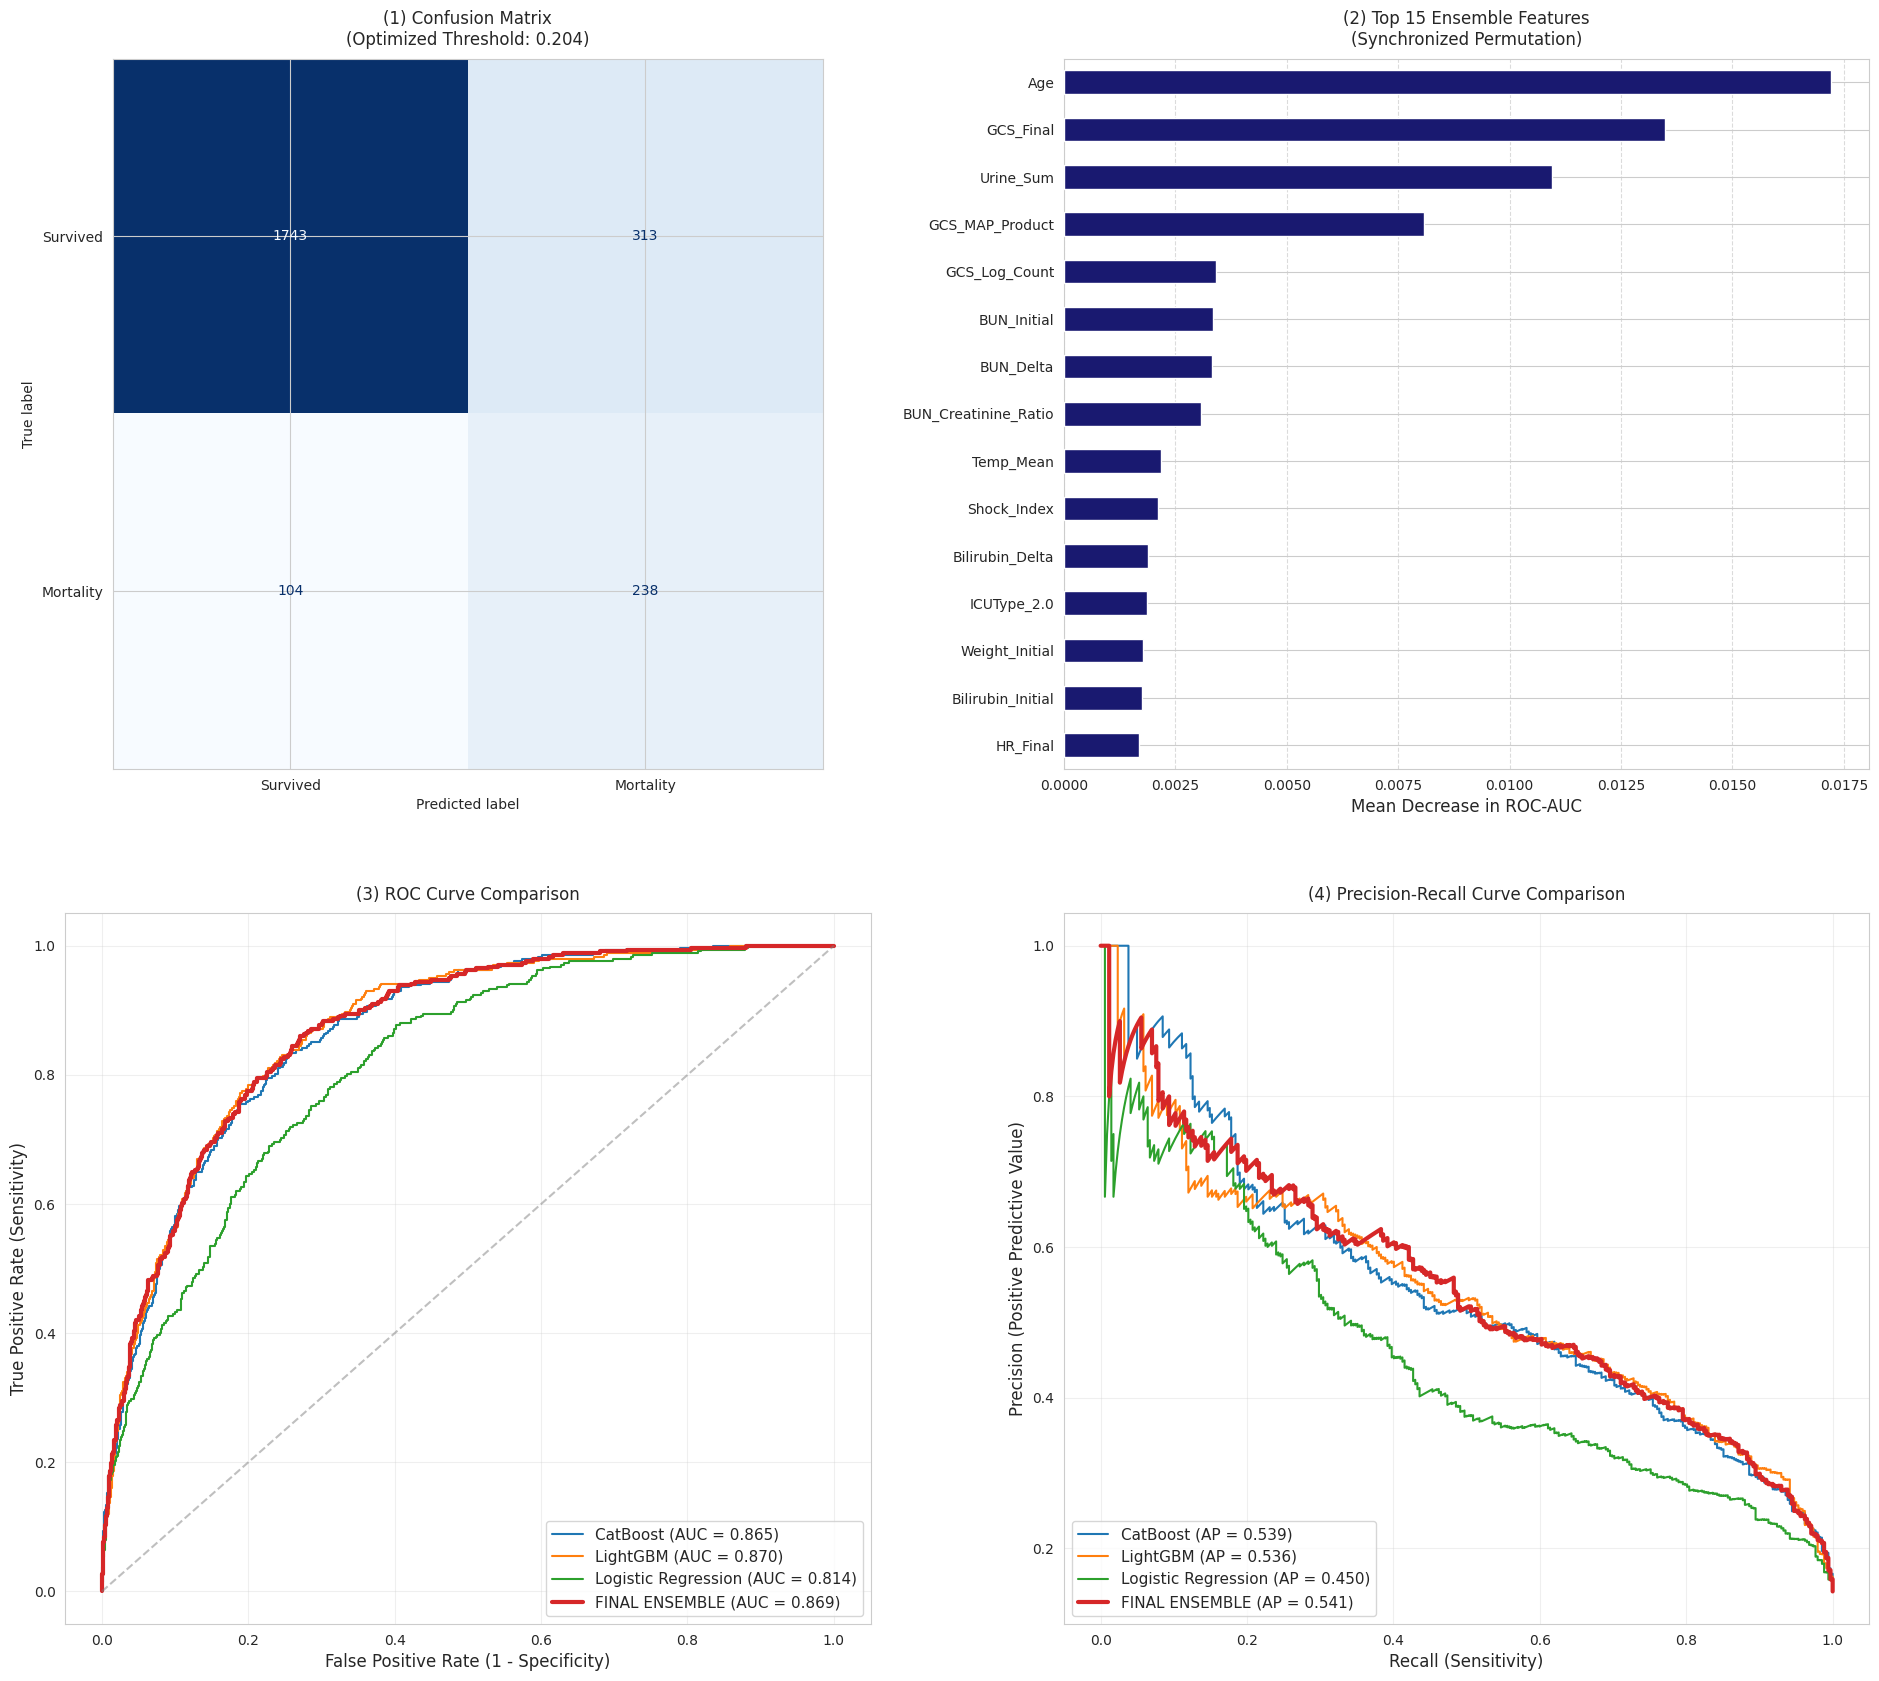

In [ ]:
prob_dict = {
    'CatBoost': prob_cb,
    'LightGBM': prob_lgb,
    'Logistic Regression': prob_lr,
    'FINAL ENSEMBLE': final_prob
}

weights = (0.5, 0.4, 0.1)

fig, axes = plt.subplots(2, 2, figsize=(20, 18))

cm = confusion_matrix(y_test, (final_prob >= best_threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Mortality'])
disp.plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title(f'(1) Confusion Matrix\n(Optimized Threshold: {best_threshold:.3f})', fontsize=12, pad=10)

feat_imp = get_ensemble_importance(X_test_tree[final_cb], X_test_tree[final_lgb], X_test_linear[final_lr], y_test, weights)

feat_imp.head(15).plot(kind='barh', ax=axes[0, 1], color='midnightblue', zorder=3)
axes[0, 1].set_title('(2) Top 15 Ensemble Features\n(Synchronized Permutation)', fontsize=12, pad=10)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Mean Decrease in ROC-AUC', fontsize=12)
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.7, zorder=0)

for name, probs in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    score = auc(fpr, tpr)
    linewidth = 3 if 'FINAL' in name else 1.5
    axes[1, 0].plot(fpr, tpr, label=f'{name} (AUC = {score:.3f})', lw=linewidth)

axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
axes[1, 0].set_title('(3) ROC Curve Comparison', fontsize=12, pad=10)
axes[1, 0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1, 0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[1, 0].legend(loc='lower right', fontsize=11)
axes[1, 0].grid(alpha=0.3)

for name, probs in prob_dict.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    linewidth = 3 if 'FINAL' in name else 1.5
    axes[1, 1].plot(rec, prec, label=f'{name} (AP = {ap:.3f})', lw=linewidth)

axes[1, 1].set_title('(4) Precision-Recall Curve Comparison', fontsize=12, pad=10)
axes[1, 1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1, 1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[1, 1].legend(loc='lower left', fontsize=11)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout(pad=5.0)
plt.savefig(path+'/ICU_Mortality_Ensemble_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# output model for deployment

In [ ]:
joblib.dump(best_cb, path+'/best_cb.pkl')
joblib.dump(best_lgb, path+'/best_lgb.pkl')
joblib.dump(best_lr, path+'/best_lr.pkl')

['/home/leewen/code/physionet/best_lr.pkl']

In [ ]:
joblib.dump(final_cb, path+'/feature_cb.pkl')
joblib.dump(final_lgb, path+'/feature_lgb.pkl')
joblib.dump(final_lr, path+'/feature_lr.pkl')

['/home/leewen/code/physionet/feature_lr.pkl']